In [1]:
import requests
import time
import json
import datetime
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
BASE = "https://dashboard.elering.ee/api"
PARAMS = {
    "start": "2026-01-01T00:00:00.000Z",
    "end":   "2026-01-01T02:00:00.000Z"  # kun 2 timer — lille response
}

endpoints = {
    "system":               "/system",
}

for name, path in endpoints.items():
    try:
        r = requests.get(BASE + path, params=PARAMS)
        data = r.json()
        
        # Hent første datapunkt og print feltnavne
        if isinstance(data, dict) and "data" in data:
            items = data["data"]
            if isinstance(items, list) and len(items) > 0:
                first = items[0]
                print(f"\n{'='*50}")
                print(f" {name} ({path})")
                print(f"   Antal datapunkter: {len(items)}")
                print(f"   Felter: {list(first.keys()) if isinstance(first, dict) else type(first)}")
                print(f"   First row: {first}")
            elif isinstance(items, dict):
                print(f"\n{'='*50}")
                print(f" {name} ({path})")
                print(f"   Felter: {list(items.keys())}")
                print(f"   Data: {items}")
        else:
            print(f"\n{'='*50}")
            print(f" {name} ({path})")
            print(f"   Raw answers: {str(data)[:200]}")
            
    except Exception as e:
        print(f"\n {name}: {e}")


 system (/system)
   Antal datapunkter: 25
   Felter: ['timestamp', 'production', 'consumption', 'losses', 'frequency', 'system_balance', 'ac_balance', 'production_renewable', 'solar_energy_production']
   First row: {'timestamp': 1767225600, 'production': 264.18, 'consumption': 1047.28, 'losses': None, 'frequency': 49.96, 'system_balance': -783.1, 'ac_balance': -131.21, 'production_renewable': 76.68, 'solar_energy_production': 4.3}


## Importing all demand data of Januaries 2019-2026

We start by importing the historical demand data from the past 8 januaries and plot them. The data is sampled every 5 minutes, which makes it very noisy, we therefore transform it to the mean of every hour.

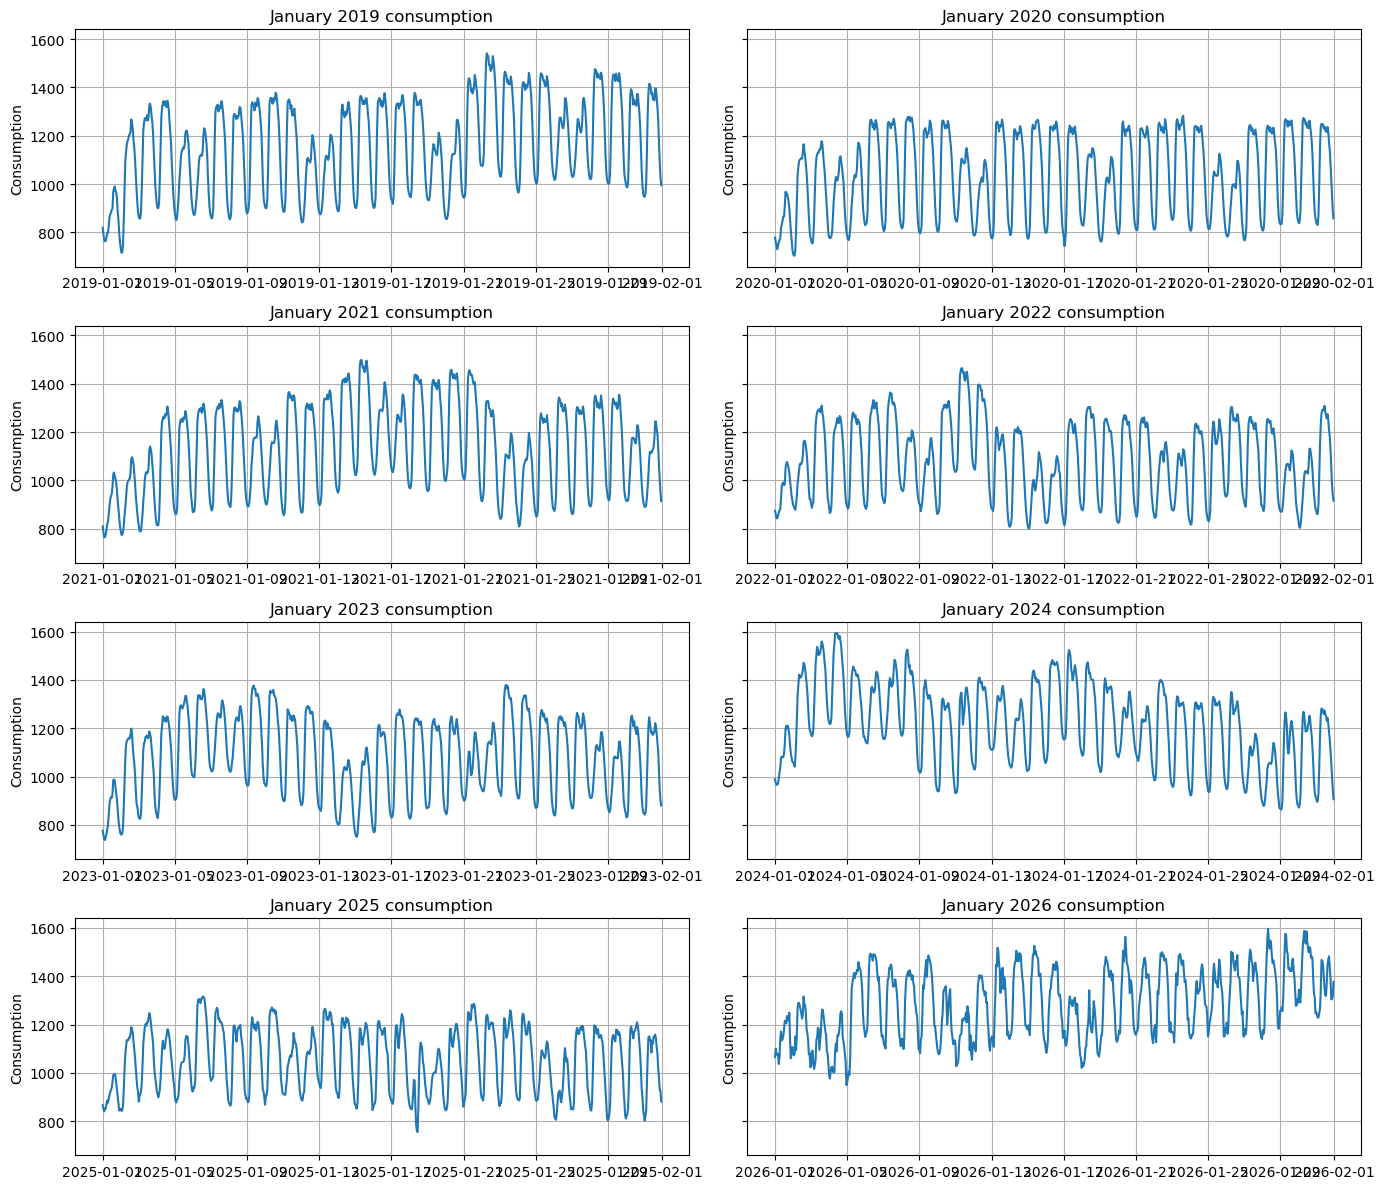

In [3]:
def fetch_january_demand(year):
    response = requests.get(
        "https://dashboard.elering.ee/api/system",
        params={
            "start": f"{year}-01-01T00:00:00.000Z",
            "end":   f"{year}-01-31T23:59:59.000Z"
        }
    )

    data = response.json()
    df = pd.DataFrame(data["data"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
    df = df.set_index("timestamp")

    demand = df["consumption"].dropna()

    # Fix known bad 2019 values
    if year == 2019:
        demand.loc["2019-01-03 11:40:00"] = demand.loc["2019-01-03 11:35:00"]
        demand.loc["2019-01-03 11:45:00"] = demand.loc["2019-01-03 11:50:00"]

    demand_hourly = demand.resample("h").mean().dropna()
    return demand_hourly


demand_series = {
    year: fetch_january_demand(year)
    for year in range(2019, 2027)
}

# Optional: keep your old variable names so later code still works
for year, series in demand_series.items():
    globals()[f"demand_jan{year}_hourly"] = series

# Plot all Januaries
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for ax, (year, series) in zip(axes, demand_series.items()):
    ax.plot(series.index, series.values)
    ax.set_title(f"January {year} consumption")
    ax.set_ylabel("Consumption")
    ax.grid(True)

for ax in axes[len(demand_series):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
def plot_acf_pacf(series, title, lags=168):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(series.dropna(), lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF: {title}")
    axes[0].grid(True)

    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF: {title}")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

### Plotting ACF's and PACF's to determine SARIMA model order

For each year, the ACF and PACF is plotted in order to spot the underlying patters and determine the model order that we should use. Since the data has a daily seasonality, we also plot the ACF and PACF of the data which is lagged by 24 hours.

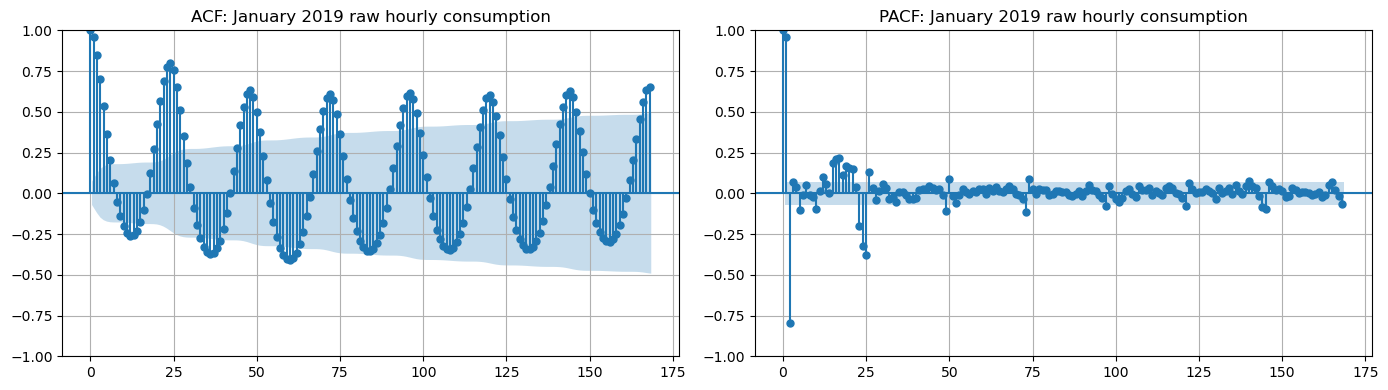

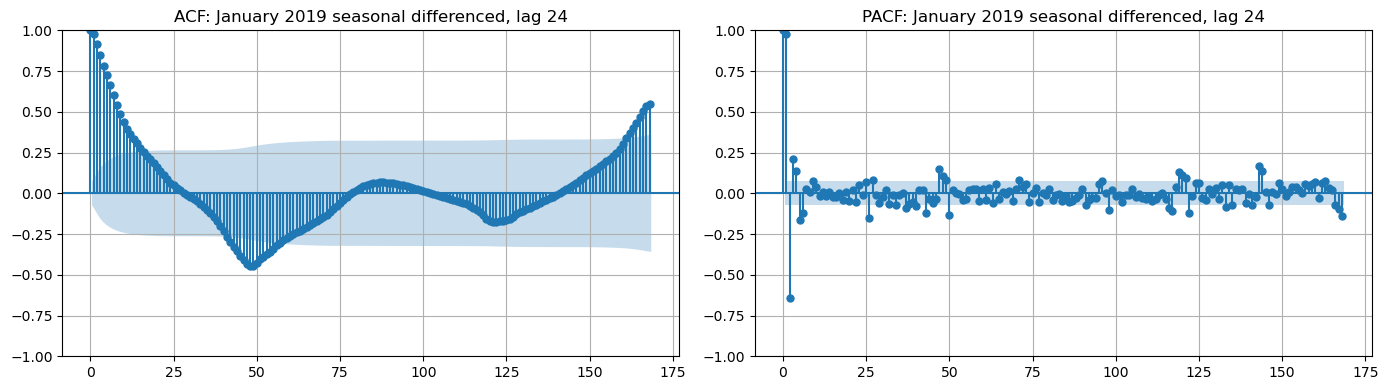

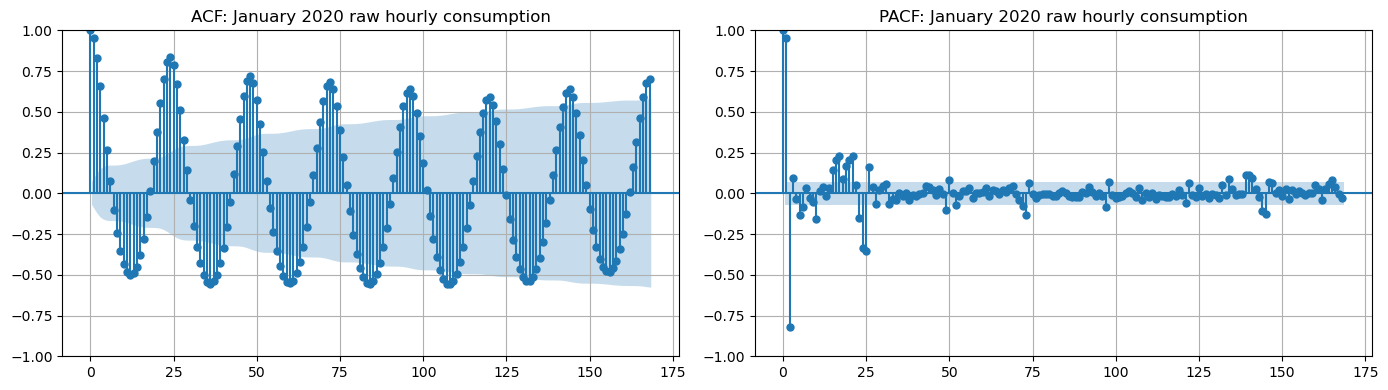

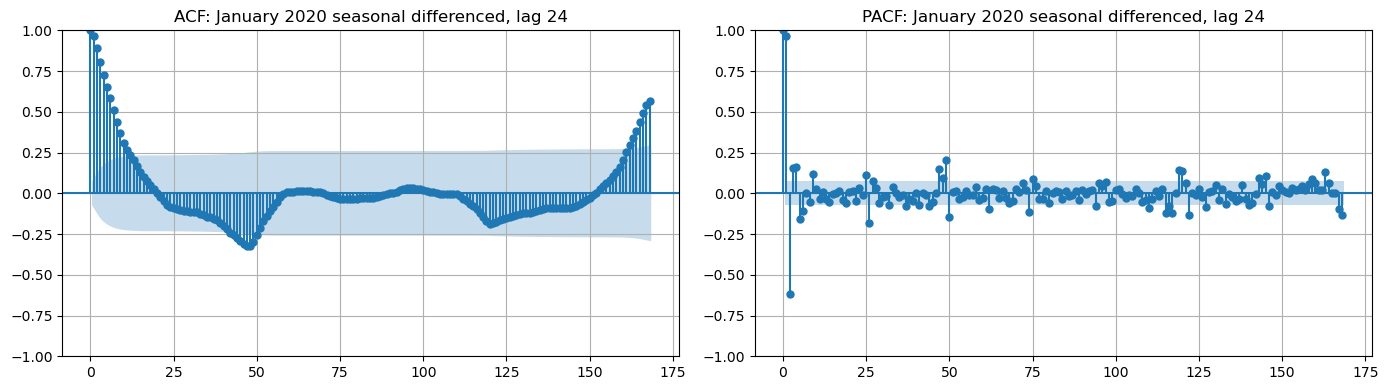

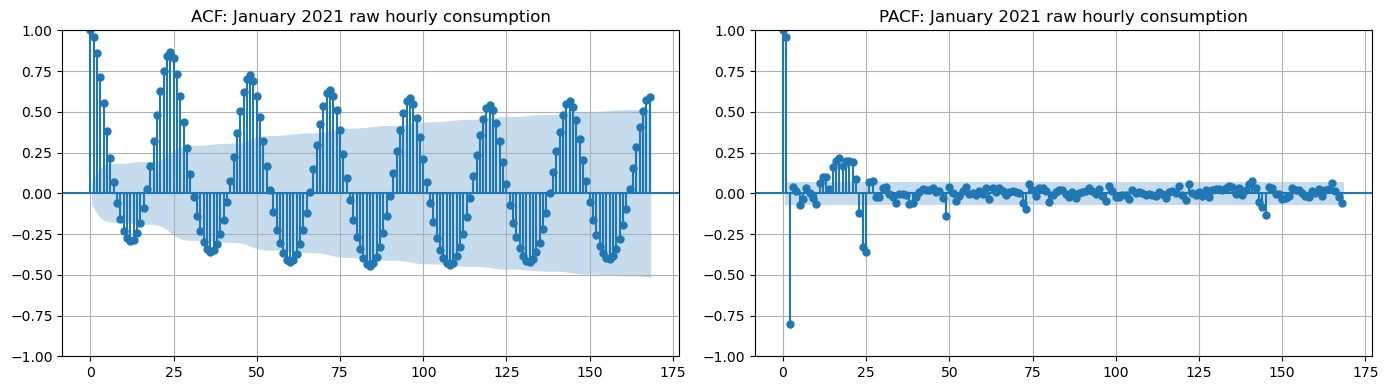

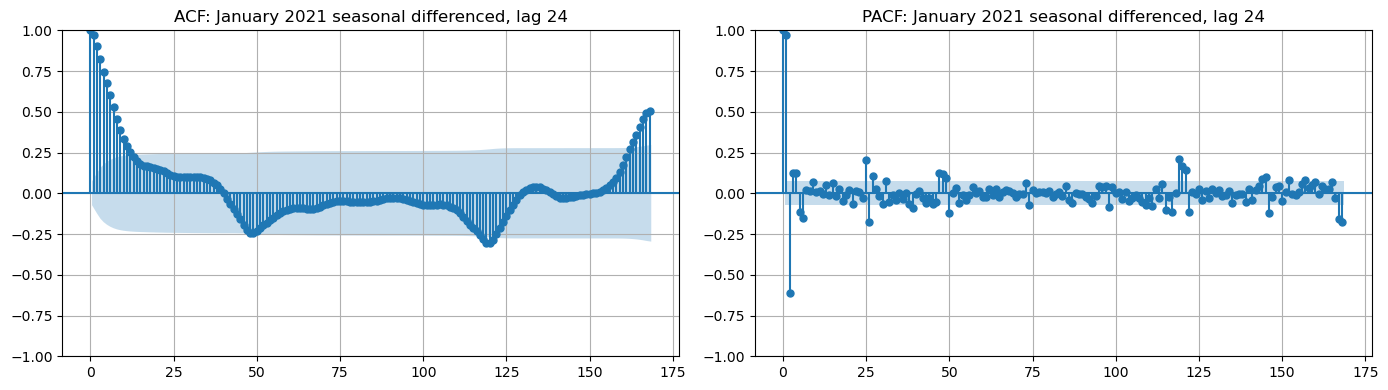

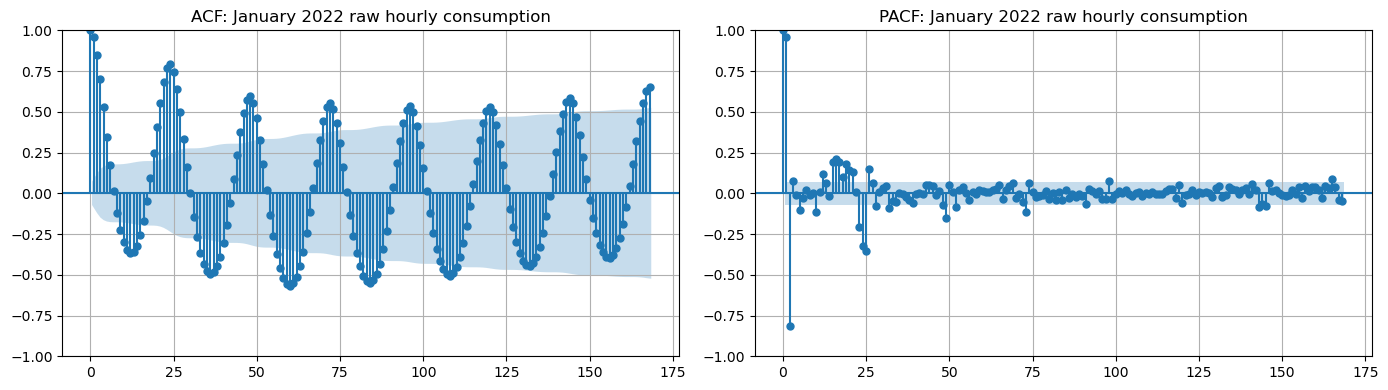

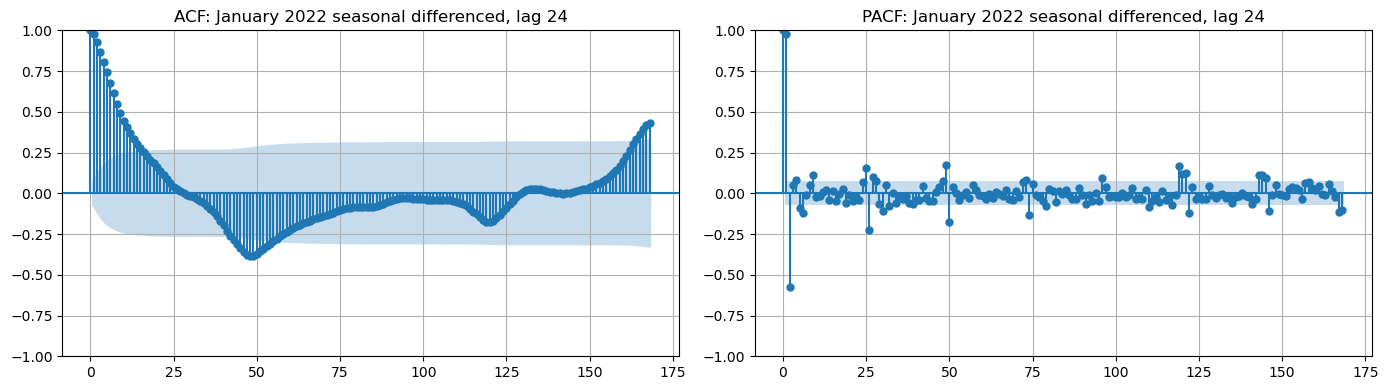

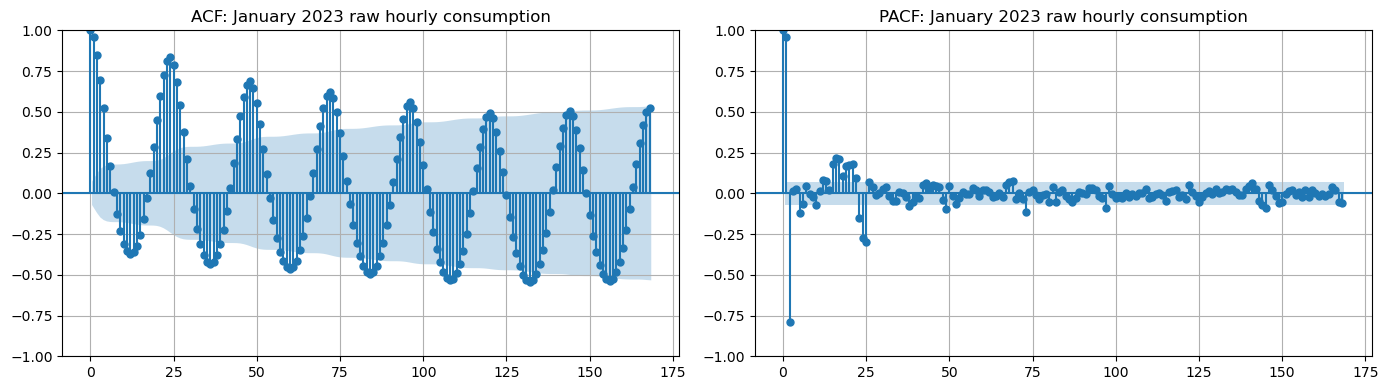

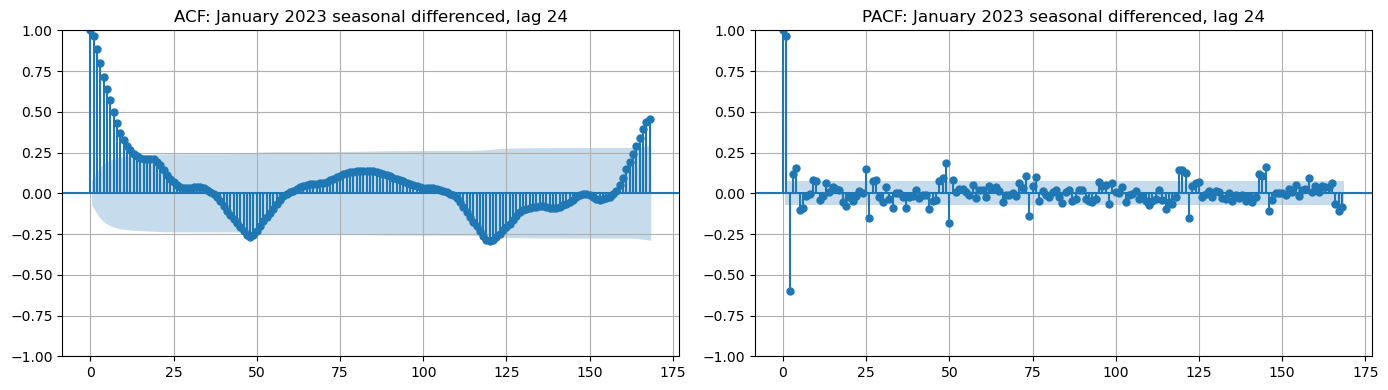

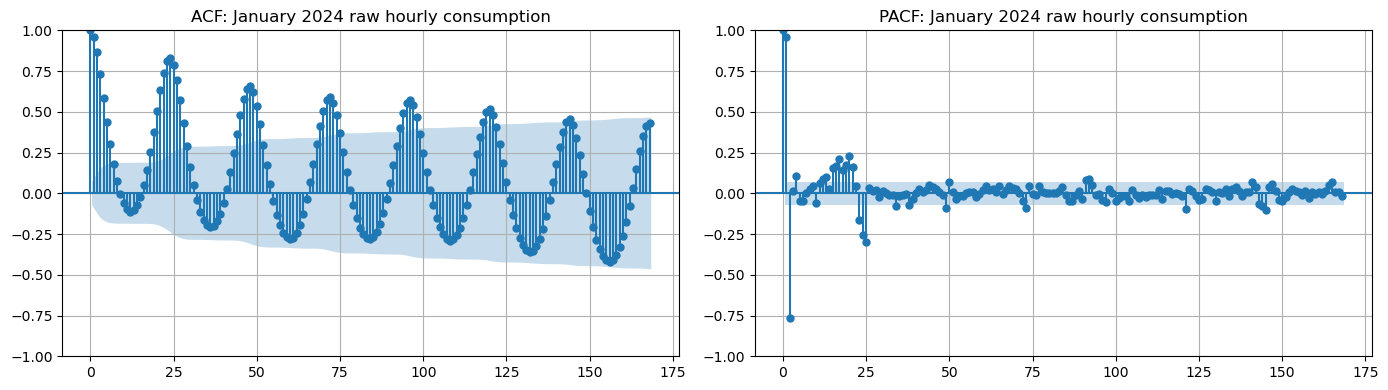

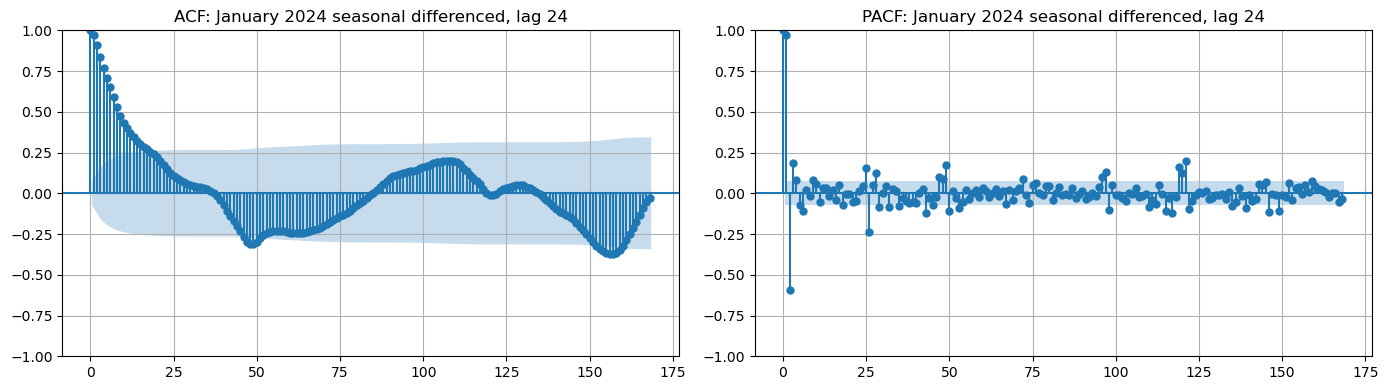

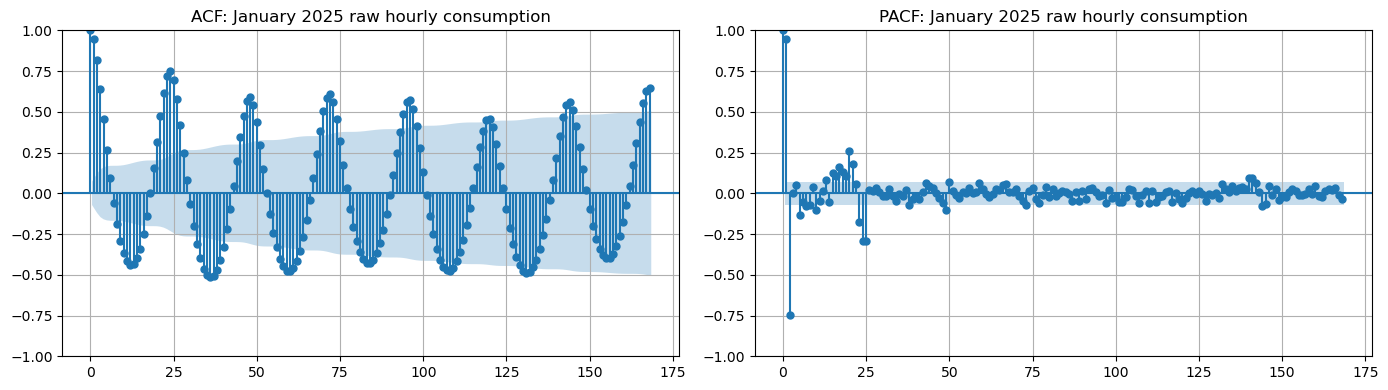

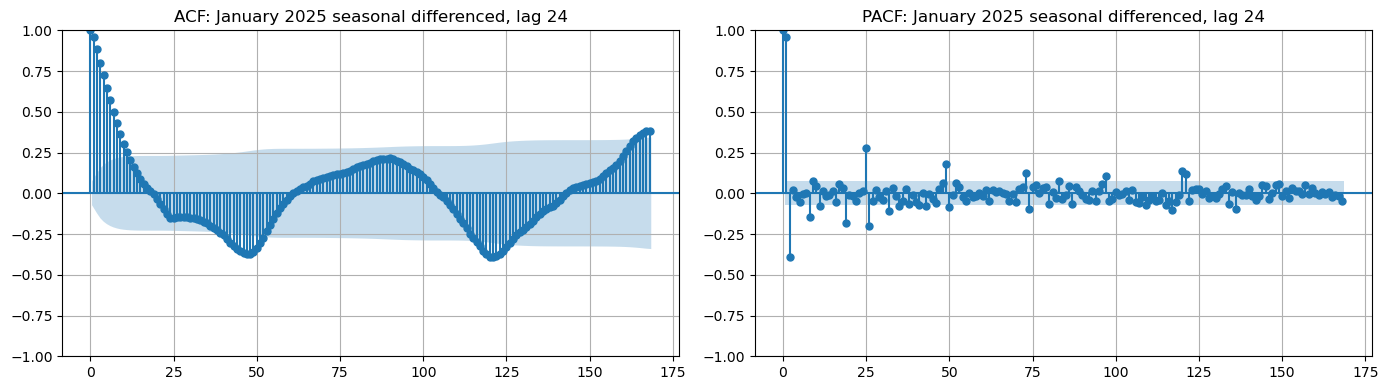

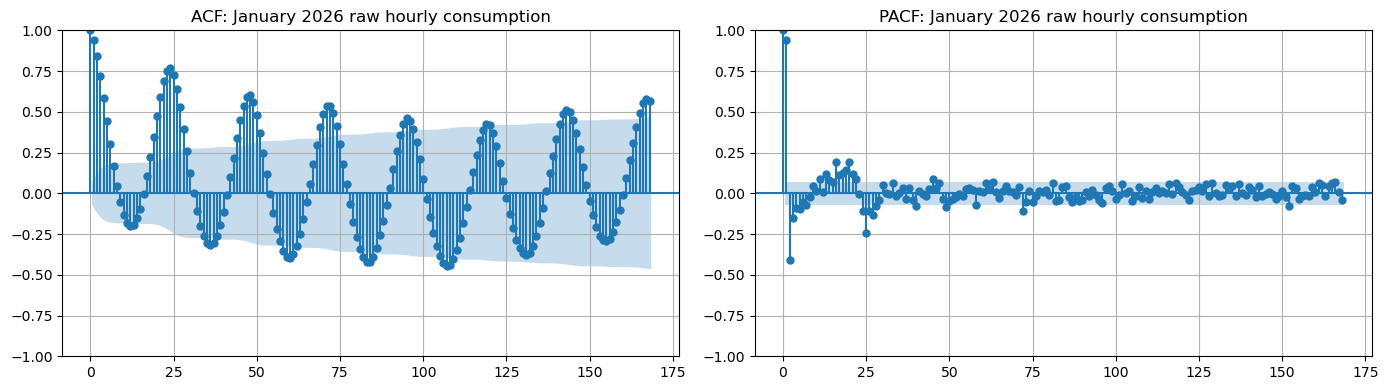

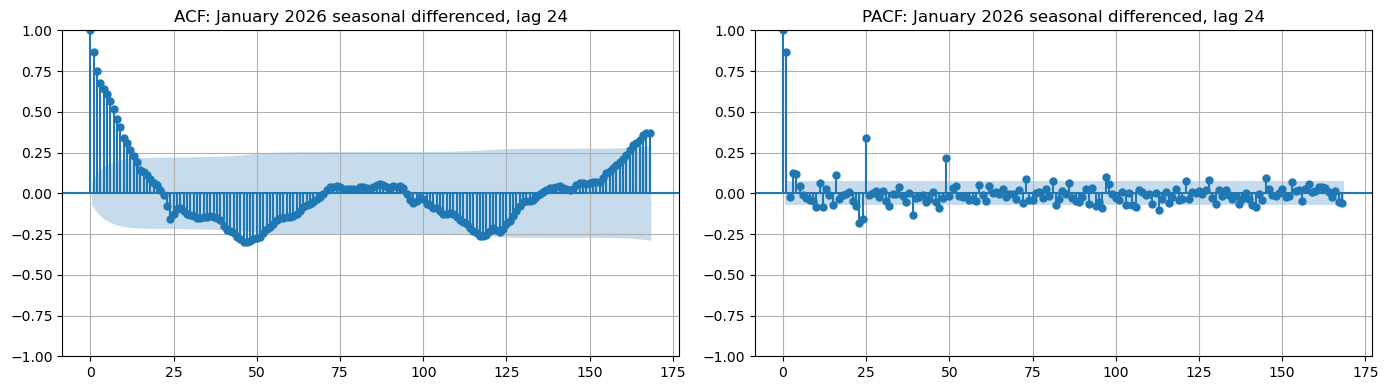

In [5]:
for year, y in demand_series.items():
    plot_acf_pacf(y, f"January {year} raw hourly consumption", lags=168)

    y_sdiff = y.diff(24)
    plot_acf_pacf(y_sdiff, f"January {year} seasonal differenced, lag 24", lags=168)

### Determining best model order

Based off both the lagged and non-lagged ACF and PACF plots, we find different candidates for the model orders. We fit a model to each of these candidates for every year, and each year we rank the models by their AIC-score.

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd
import numpy as np
import warnings
from IPython.display import display

# -----------------------------
# 2. Define candidate SARIMA models
# -----------------------------
candidate_models = [
    ((1, 0, 1), (1, 1, 1, 24)),
    ((2, 0, 1), (1, 1, 1, 24)),
    ((1, 0, 2), (1, 1, 1, 24)),
    ((2, 0, 2), (1, 1, 1, 24)),
    ((3, 0, 2), (1, 1, 1, 24)),

    ((2, 0, 2), (0, 1, 1, 24)),
    ((2, 0, 2), (1, 1, 0, 24)),
    ((2, 0, 2), (2, 1, 1, 24)),
    ((2, 0, 2), (1, 1, 2, 24)),
]

# Choose ranking metric
rank_metric = "AIC"   # use "BIC" if you prefer simpler models

# -----------------------------
# 3. Fit models year by year
# -----------------------------
all_results = []

for year, y in {k: v for k, v in demand_series.items() if k <= 2025}.items():

    y = y.dropna()

    yearly_results = []

    for model_id, (order, seasonal_order) in enumerate(candidate_models):

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                model = SARIMAX(
                    y,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                fit = model.fit(disp=False, maxiter=100, method="lbfgs")

            lb = acorr_ljungbox(
                fit.resid.dropna(),
                lags=[24],
                return_df=True
            )

            yearly_results.append({
                "year": year,
                "model_id": model_id,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fit.aic,
                "BIC": fit.bic,
                "Ljung-Box p-value lag 24": lb.loc[24, "lb_pvalue"],
                "converged": fit.mle_retvals.get("converged", None)
            })

        except Exception as e:
            yearly_results.append({
                "year": year,
                "model_id": model_id,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": np.nan,
                "BIC": np.nan,
                "Ljung-Box p-value lag 24": np.nan,
                "converged": False,
                "error": str(e)
            })

    yearly_table = pd.DataFrame(yearly_results)

    # Sort by chosen ranking metric
    yearly_table = yearly_table.sort_values(rank_metric, ascending=True).reset_index(drop=True)

    # Score: best = 5, second = 4, ..., fifth = 1
    yearly_table["score"] = 0
    yearly_table.loc[:10, "score"] = list(range(9, 0, -1))

    print(f"\nModel comparison for January {year}, ranked by {rank_metric}")
    display(yearly_table)

    all_results.append(yearly_table)

# -----------------------------
# 4. Combine all yearly results
# -----------------------------
all_results_df = pd.concat(all_results, ignore_index=True)

# -----------------------------
# 5. Total score across all years
# -----------------------------
score_summary = (
    all_results_df
    .groupby(["order", "seasonal_order"], as_index=False)
    .agg(
        total_score=("score", "sum"),
        mean_score=("score", "mean"),
        mean_AIC=("AIC", "mean"),
        mean_BIC=("BIC", "mean"),
        median_AIC=("AIC", "median"),
        median_BIC=("BIC", "median"),
        first_places=("score", lambda x: (x == 9).sum()),
        years_tested=("score", "count")
    )
    .sort_values(
        ["total_score", "first_places", "mean_AIC"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

print("\nOverall model score across all years")
display(score_summary)

# -----------------------------
# 6. Extract the overall best model
# -----------------------------
best_overall_model = score_summary.iloc[0]

print("Best overall model:")
print(f"order = {best_overall_model['order']}")
print(f"seasonal_order = {best_overall_model['seasonal_order']}")
print(f"total_score = {best_overall_model['total_score']}")
print(f"first_places = {best_overall_model['first_places']}")
print(f"mean_AIC = {best_overall_model['mean_AIC']:.2f}")
print(f"mean_BIC = {best_overall_model['mean_BIC']:.2f}")


Model comparison for January 2019, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2019,8,"(2, 0, 2)","(1, 1, 2, 24)",5386.263459,5422.309732,3.179220e-48,True,9
1,2019,7,"(2, 0, 2)","(2, 1, 1, 24)",5393.481870,5429.540092,7.077563e-59,True,8
2,2019,4,"(3, 0, 2)","(1, 1, 1, 24)",5602.762782,5639.091022,1.763157e-31,True,7
3,2019,3,"(2, 0, 2)","(1, 1, 1, 24)",5609.670798,5641.458008,2.527559e-43,True,6
4,2019,2,"(1, 0, 2)","(1, 1, 1, 24)",5615.054503,5642.300683,8.461299e-56,True,5
5,2019,1,"(2, 0, 1)","(1, 1, 1, 24)",5661.079836,5688.334668,7.106095e-24,True,4
6,2019,5,"(2, 0, 2)","(0, 1, 1, 24)",5664.991026,5692.237206,1.516172e-31,True,3
7,2019,0,"(1, 0, 1)","(1, 1, 1, 24)",5748.040280,5770.752639,4.144886e-46,True,2
8,2019,6,"(2, 0, 2)","(1, 1, 0, 24)",5756.041025,5783.295856,9.721176e-76,True,1



Model comparison for January 2020, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2020,8,"(2, 0, 2)","(1, 1, 2, 24)",5387.353980,5423.400252,1.420381e-85,True,9
1,2020,7,"(2, 0, 2)","(2, 1, 1, 24)",5406.746295,5442.804517,4.396405e-73,True,8
2,2020,4,"(3, 0, 2)","(1, 1, 1, 24)",5607.124483,5643.452723,9.330519e-38,True,7
3,2020,3,"(2, 0, 2)","(1, 1, 1, 24)",5607.417590,5639.204800,8.882372e-72,True,6
4,2020,2,"(1, 0, 2)","(1, 1, 1, 24)",5607.872202,5635.118382,2.625616e-81,True,5
5,2020,5,"(2, 0, 2)","(0, 1, 1, 24)",5653.303208,5680.549388,1.147255e-57,True,4
6,2020,1,"(2, 0, 1)","(1, 1, 1, 24)",5657.889608,5685.144439,8.820854e-27,True,3
7,2020,0,"(1, 0, 1)","(1, 1, 1, 24)",5736.642775,5759.355135,1.195117e-48,True,2
8,2020,6,"(2, 0, 2)","(1, 1, 0, 24)",5771.732521,5798.987353,1.729244e-178,True,1



Model comparison for January 2021, ranked by AIC


...


Model comparison for January 2025, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2025,8,"(2, 0, 2)","(1, 1, 2, 24)",5903.010486,5939.044791,2.042232e-122,True,9
1,2025,7,"(2, 0, 2)","(2, 1, 1, 24)",5914.279232,5950.325505,2.861702e-93,True,8
2,2025,3,"(2, 0, 2)","(1, 1, 1, 24)",6111.391155,6143.168256,1.861172e-88,True,7
3,2025,2,"(1, 0, 2)","(1, 1, 1, 24)",6113.915369,6141.152885,1.001365e-92,True,6
4,2025,5,"(2, 0, 2)","(0, 1, 1, 24)",6113.915417,6141.152932,1.232347e-65,True,5
5,2025,1,"(2, 0, 1)","(1, 1, 1, 24)",6120.005932,6147.252112,7.017339e-30,True,4
6,2025,0,"(1, 0, 1)","(1, 1, 1, 24)",6141.520312,6164.225462,2.662613e-55,True,3
7,2025,4,"(3, 0, 2)","(1, 1, 1, 24)",6142.743710,6179.060398,2.282678e-15,False,2
8,2025,6,"(2, 0, 2)","(1, 1, 0, 24)",6250.016649,6277.262829,5.900925e-234,True,1



Overall model score across all years


,order,seasonal_order,total_score,mean_score,mean_AIC,mean_BIC,median_AIC,median_BIC,first_places,years_tested
0,"(2, 0, 2)","(1, 1, 2, 24)",61,8.714286,5464.194502,5500.239065,5387.353980,5423.400252,5,7
1,"(2, 0, 2)","(2, 1, 1, 24)",58,8.285714,5473.387470,5509.443985,5406.746295,5442.804517,2,7
2,"(2, 0, 2)","(1, 1, 1, 24)",44,6.285714,5679.997397,5711.783163,5607.417590,5639.204800,0,7
3,"(3, 0, 2)","(1, 1, 1, 24)",43,6.142857,5681.790317,5718.116906,5602.762782,5639.091022,0,7
4,"(1, 0, 2)","(1, 1, 1, 24)",36,5.142857,5683.306876,5710.551818,5607.872202,5635.118382,0,7
5,"(2, 0, 2)","(0, 1, 1, 24)",26,3.714286,5717.591218,5744.836160,5653.303208,5680.549388,0,7
6,"(2, 0, 1)","(1, 1, 1, 24)",25,3.571429,5713.559013,5740.812608,5657.889608,5685.144439,0,7
7,"(1, 0, 1)","(1, 1, 1, 24)",15,2.142857,5778.561132,5801.272462,5723.542558,5746.254917,0,7
8,"(2, 0, 2)","(1, 1, 0, 24)",7,1.000000,5838.659332,5865.912928,5772.423031,5799.677863,0,7


Best overall model:
order = (2, 0, 2)
seasonal_order = (1, 1, 2, 24)
total_score = 61
first_places = 5
mean_AIC = 5464.19
mean_BIC = 5500.24


As we can see the model with order (p,d,q) = (2,0,2) and seasonal order = (1,1,2,24) was selected as the best overall model. We therefore continue using it.

## Fetch weather data

Since the demand is influenced by external factors such as the weather, we now also import temperature and the windspeed and use it for our model. Our theory is that in cold months and especially if there is a lot of wind, people will need more electricity to keep warm and their energy demand will therefore be higher. We would also have liked to use other external data such as industrial activity, but we didn't have access to the neccessary API.

In [7]:
def fetch_weather_from_openmeteo(lat, lon, start_date, end_date, location_name=""):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,wind_speed_10m",
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",
        "timezone": "UTC"
    }

    print(f"Fetching weather: {location_name}")

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    hourly = data["hourly"]

    df = pd.DataFrame({
        "timestamp": pd.to_datetime(hourly["time"]),
        "temperature": hourly["temperature_2m"],
        "wind_speed": hourly["wind_speed_10m"]
    })

    df = df.set_index("timestamp")
    return df


weather_series = {}

for year in range(2019, 2027):
    weather_series[year] = fetch_weather_from_openmeteo(
        lat=59.437,
        lon=24.753,
        start_date=f"{year}-01-01",
        end_date=f"{year}-01-31",
        location_name=f"Estonia January {year}"
    )

Fetching weather: Estonia January 2019
Fetching weather: Estonia January 2020
Fetching weather: Estonia January 2021
Fetching weather: Estonia January 2022
Fetching weather: Estonia January 2023
Fetching weather: Estonia January 2024
Fetching weather: Estonia January 2025
Fetching weather: Estonia January 2026


In [8]:
combined_dfs = {}

for year in range(2019, 2026):
    demand = demand_series[year].rename("consumption")
    weather = weather_series[year][["temperature", "wind_speed"]].copy()
    weather["temperature_roll24"] = weather["temperature"].rolling(24, min_periods=1).mean()

    df = pd.concat([demand, weather], axis=1).dropna()

    df["weekend"] = (df.index.dayofweek >= 5).astype(int)

    combined_dfs[year] = df

    print(year, df.shape, df.index.min(), df.index.max())

2019 (744, 5) 2019-01-01 00:00:00 2019-01-31 23:00:00
2020 (744, 5) 2020-01-01 00:00:00 2020-01-31 23:00:00
2021 (744, 5) 2021-01-01 00:00:00 2021-01-31 23:00:00
2022 (744, 5) 2022-01-01 00:00:00 2022-01-31 23:00:00
2023 (744, 5) 2023-01-01 00:00:00 2023-01-31 23:00:00
2024 (744, 5) 2024-01-01 00:00:00 2024-01-31 23:00:00
2025 (743, 5) 2025-01-01 00:00:00 2025-01-31 23:00:00


## Fitting best selected model with exog features

In [9]:
features = ["temperature_roll24", "wind_speed", "weekend"]

order = (2, 0, 2)
seasonal_order = (1, 1, 2, 24)

fitted_models = {}

for year, df in combined_dfs.items():
    y = df["consumption"]
    X = df[features]

    model = SARIMAX(
        y,
        exog=X,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)
    fitted_models[year] = fit

    print(f"{year}: AIC = {fit.aic:.2f}, BIC = {fit.bic:.2f}")

/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2019: AIC = 5799.89, BIC = 5849.46


/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2020: AIC = 5402.49, BIC = 5452.06


/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

2023: AIC = 5510.41, BIC = 5559.98


/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2024: AIC = 5720.01, BIC = 5769.58


/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2025: AIC = 5985.28, BIC = 6034.83


# Estimating exog coefficients and standard deviations

In [10]:
coef_rows = []

for year, fit in fitted_models.items():
    for name in fit.params.index:
        coef_rows.append({
            "year": year,
            "parameter": name,
            "estimate": fit.params[name],
            "p_value": fit.pvalues[name]
        })

coef_table = pd.DataFrame(coef_rows)

display(coef_table[coef_table["year"] == 2019])
display(coef_table[coef_table["year"] == 2020])
display(coef_table[coef_table["year"] == 2021])
display(coef_table[coef_table["year"] == 2022])
display(coef_table[coef_table["year"] == 2023])
display(coef_table[coef_table["year"] == 2024])
display(coef_table[coef_table["year"] == 2025])

,year,parameter,estimate,p_value
0,2019,temperature_roll24,-12.520412,4.359073e-11
1,2019,wind_speed,-0.429635,1.963765e-01
2,2019,weekend,-96.601203,1.073990e-227
3,2019,ar.L1,1.841709,1.495783e-230
4,2019,ar.L2,-0.850395,1.923119e-61
5,2019,ma.L1,-0.591127,2.659951e-20
6,2019,ma.L2,-0.335201,3.563091e-16
7,2019,ar.S.L24,-0.423398,3.677638e-38
8,2019,ma.S.L24,-0.095809,5.709527e-03
9,2019,ma.S.L48,-0.773540,4.249887e-177


,year,parameter,estimate,p_value
11,2020,temperature_roll24,-8.253799,1.768760e-01
12,2020,wind_speed,-0.878510,6.890533e-04
13,2020,weekend,-3.612582,5.336944e-01
14,2020,ar.L1,1.122366,1.177415e-47
15,2020,ar.L2,-0.199459,1.039016e-02
16,2020,ma.L1,0.536392,2.436354e-12
17,2020,ma.L2,0.358218,5.434642e-11
18,2020,ar.S.L24,-0.189158,7.455235e-03
19,2020,ma.S.L24,-0.620514,1.113061e-22
20,2020,ma.S.L48,-0.603075,1.011023e-13


,year,parameter,estimate,p_value
22,2021,temperature_roll24,-31.697668,3.803796e-13
23,2021,wind_speed,2.287601,3.126540e-09
24,2021,weekend,-23.423614,3.613992e-14
25,2021,ar.L1,1.452000,3.044497e-96
26,2021,ar.L2,-0.509894,1.849397e-13
27,2021,ma.L1,0.145245,8.669161e-02
28,2021,ma.L2,0.068059,2.311178e-01
29,2021,ar.S.L24,-0.173888,5.987898e-02
30,2021,ma.S.L24,-0.695699,3.241846e-16
31,2021,ma.S.L48,-0.539212,1.806235e-07


,year,parameter,estimate,p_value
33,2022,temperature_roll24,-14.339354,1.517599e-14
34,2022,wind_speed,-1.834227,2.821348e-06
35,2022,weekend,-130.010403,3.668536e-164
36,2022,ar.L1,1.664170,1.079576e-88
37,2022,ar.L2,-0.747870,1.687646e-25
38,2022,ma.L1,-0.522314,2.569644e-08
39,2022,ma.L2,-0.050552,4.325476e-01
40,2022,ar.S.L24,-0.415522,3.700065e-12
41,2022,ma.S.L24,-0.197661,2.676863e-03
42,2022,ma.S.L48,-0.719192,1.273777e-56


,year,parameter,estimate,p_value
44,2023,temperature_roll24,-37.434981,3.157543e-09
45,2023,wind_speed,2.106245,2.343817e-08
46,2023,weekend,-16.344269,3.568960e-04
47,2023,ar.L1,0.540180,2.872861e-04
48,2023,ar.L2,0.421712,4.040127e-03
49,2023,ma.L1,0.991686,1.157087e-12
50,2023,ma.L2,0.411457,1.013965e-10
51,2023,ar.S.L24,-0.451743,1.403659e-14
52,2023,ma.S.L24,-0.301594,8.569074e-12
53,2023,ma.S.L48,-0.793741,4.681902e-53


,year,parameter,estimate,p_value
55,2024,temperature_roll24,-12.843575,2.719976e-14
56,2024,wind_speed,-0.761894,2.489429e-02
57,2024,weekend,-91.365652,8.107746e-222
58,2024,ar.L1,0.921830,5.566415e-17
59,2024,ar.L2,-0.056546,5.756997e-01
60,2024,ma.L1,0.439491,3.037215e-05
61,2024,ma.L2,0.264697,7.301805e-06
62,2024,ar.S.L24,-0.394616,4.152374e-07
63,2024,ma.S.L24,-0.360219,1.052557e-08
64,2024,ma.S.L48,-0.770685,8.894508e-23


,year,parameter,estimate,p_value
66,2025,temperature_roll24,-4.448159,1.274442e-01
67,2025,wind_speed,-1.532948,2.138305e-03
68,2025,weekend,-74.526477,1.386153e-120
69,2025,ar.L1,1.550727,6.919303e-34
70,2025,ar.L2,-0.633188,9.159402e-09
71,2025,ma.L1,-0.306578,2.284803e-02
72,2025,ma.L2,-0.083883,2.921355e-01
73,2025,ar.S.L24,-0.363178,1.250973e-02
74,2025,ma.S.L24,-0.354520,1.309119e-02
75,2025,ma.S.L48,-0.439290,1.355596e-04


## Plotting residuals

We now plot the ACF and PACF of the residuals from 2019 to 2025, as these are the SARIMAX models we use in the Monte Carlo simulation. We want to see if there is still a lot of underlying data or if our model was able to capture all of it.

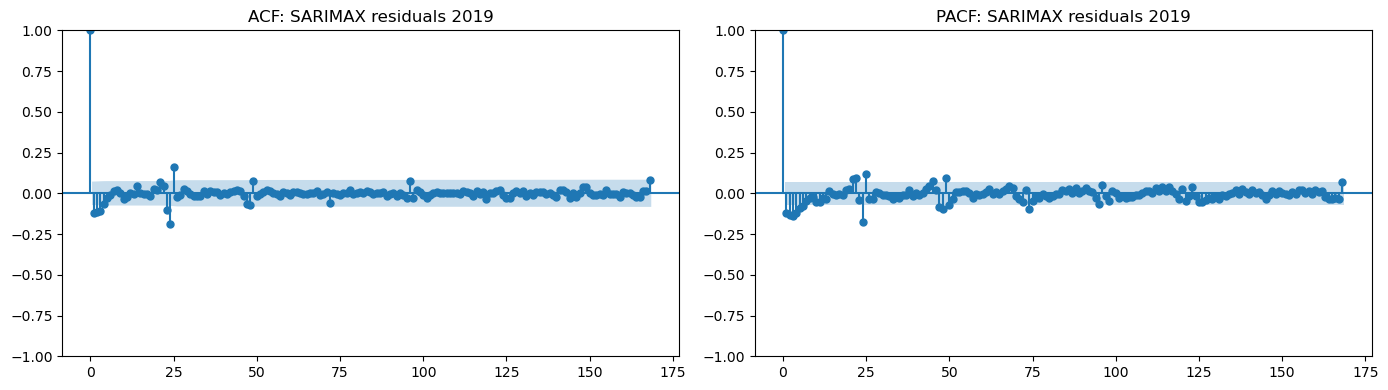

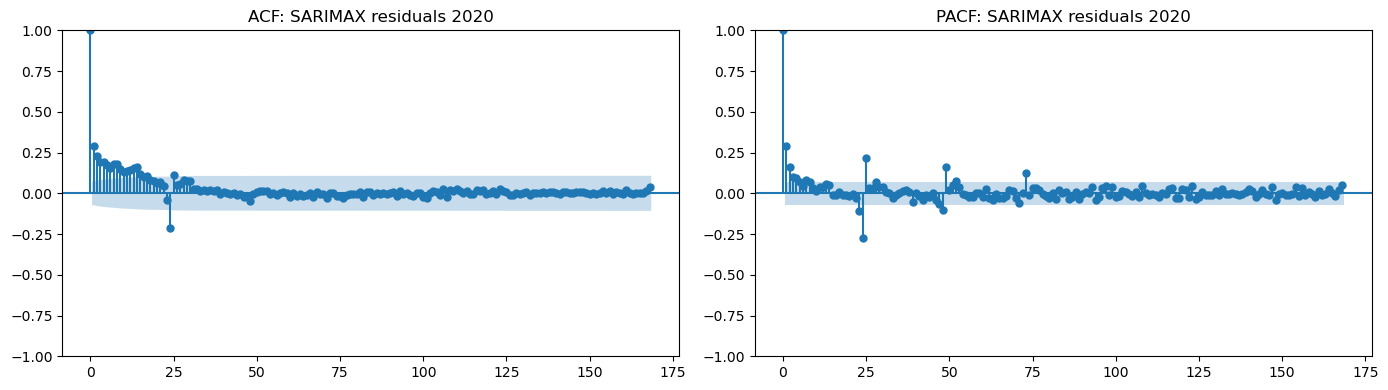

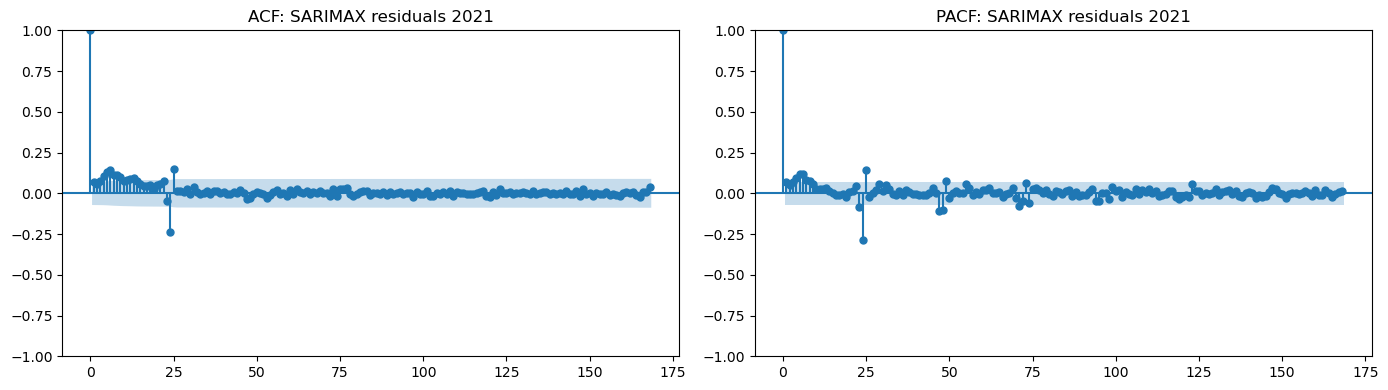

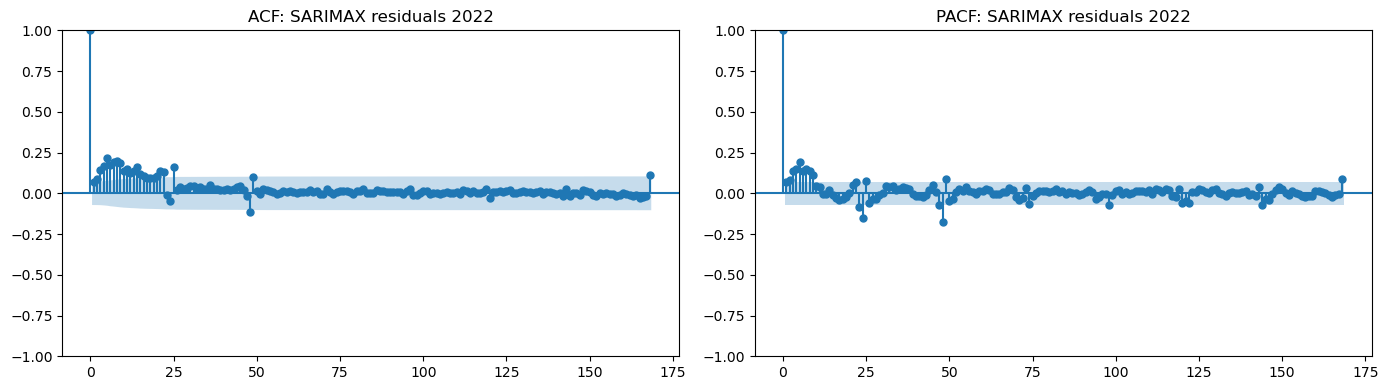

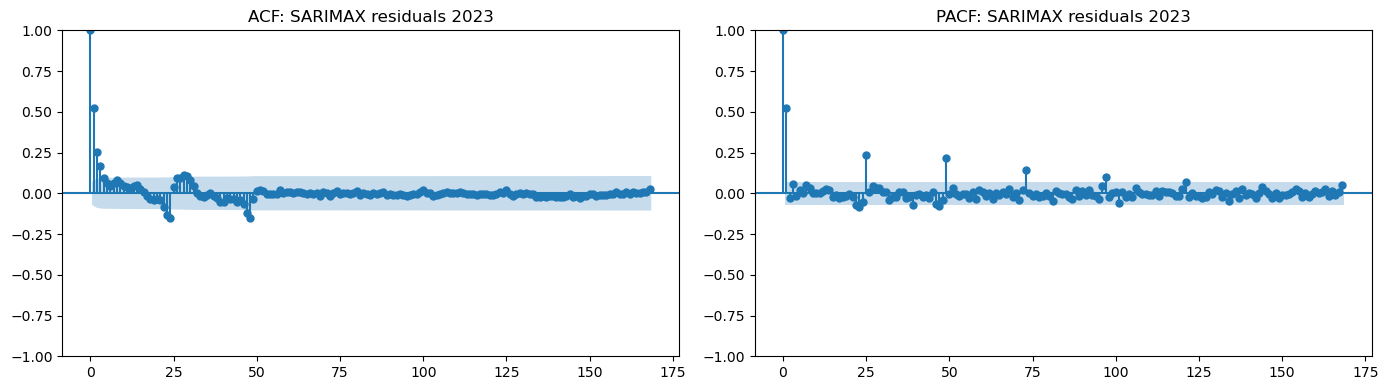

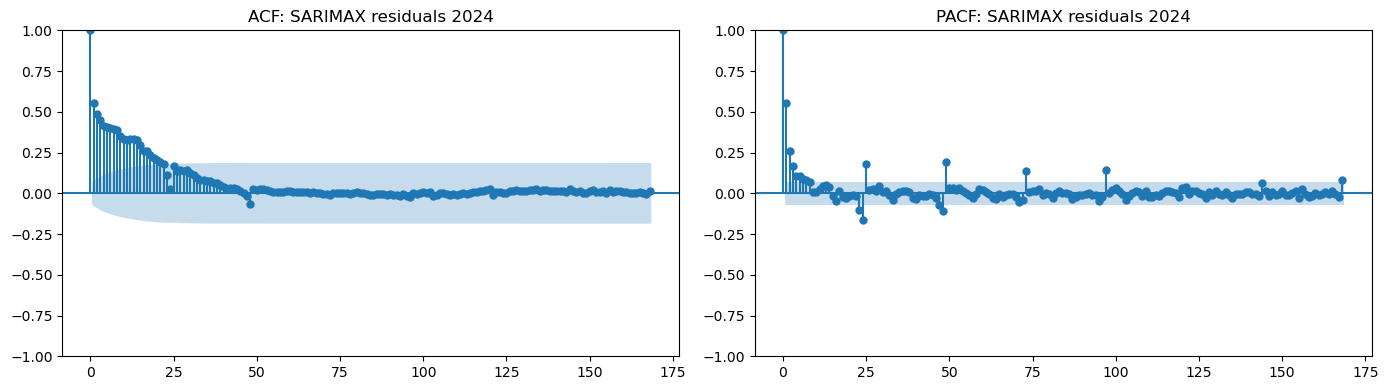

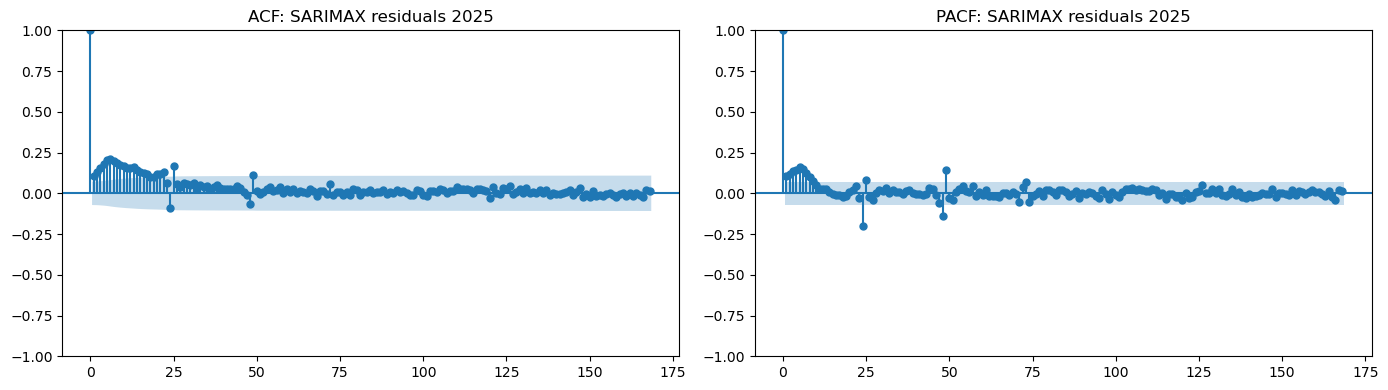

In [11]:
for year, fit in fitted_models.items():
    resid = fit.resid.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(resid, lags=168, ax=axes[0])
    axes[0].set_title(f"ACF: SARIMAX residuals {year}")

    plot_pacf(resid, lags=168, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF: SARIMAX residuals {year}")

    plt.tight_layout()
    plt.show()

Even though a little autocorrelation still remains in the residuals, the overall patterns are captured by the SARIMAX model. 

## Monte Carlo using weather data and beta decides how much they affect the demand

We now begin implementing the Monte Carlo simulations: We do this by drawing a random january from 2019 to 2025 and use the coefficients of this SARIMAX model. Then a forecast is made based off these coefficients. We furthermore draw how much the average temperature of the past 24 hours, the windspeed and wether it is the weekend or not affects the demand, based of their earlier estimated coefficients and standard deviations. 

In [12]:
features = ["temperature_roll24", "wind_speed", "weekend"]

beta_rows = []

for year, fit in fitted_models.items():
    for feature in features:
        beta_rows.append({
            "year": year,
            "feature": feature,
            "beta": fit.params[feature]
        })

beta_df = pd.DataFrame(beta_rows)

beta_stats = (
    beta_df
    .groupby("feature")["beta"]
    .agg(["mean", "std"])
    .reset_index()
)

display(beta_df)
display(beta_stats)


def simulate_demand_ensemble_with_random_betas(
    fitted_models,
    X_future,
    beta_stats,
    features,
    n_sims=1000,
    seed=123
):
    rng = np.random.default_rng(seed)

    years = list(fitted_models.keys())
    sims = []

    # Convert beta stats to dictionaries
    beta_mean = beta_stats.set_index("feature")["mean"].to_dict()
    beta_std = beta_stats.set_index("feature")["std"].to_dict()

    for i in range(n_sims):

        # 1. Randomly choose one historical SARIMAX model
        year = rng.choice(years)
        fit = fitted_models[year]

        # 2. Baseline forecast using the chosen model's original coefficients
        forecast = fit.get_forecast(
            steps=len(X_future),
            exog=X_future
        ).predicted_mean

        # 3. Randomly draw new weather effects
        beta_adjustment = np.zeros(len(X_future))

        for feature in features:
            beta_draw = rng.normal(
                beta_mean[feature],
                beta_std[feature]
            )

            beta_original = fit.params[feature]

            # Adjustment relative to the chosen model's original beta
            beta_adjustment += (
                beta_draw - beta_original
            ) * X_future[feature].values

        # 4. Random residual noise
        resid = fit.resid.dropna()
        sigma = resid.std()

        noise = rng.normal(
            loc=0,
            scale=sigma,
            size=len(X_future)
        )

        # 5. Final simulated demand
        sim = pd.Series(
            forecast.values + beta_adjustment + noise,
            index=X_future.index,
            name=f"sim_{i+1}"
        )

        sims.append(sim)

    return pd.concat(sims, axis=1)

,year,feature,beta
0,2019,temperature_roll24,-12.520412
1,2019,wind_speed,-0.429635
2,2019,weekend,-96.601203
3,2020,temperature_roll24,-8.253799
4,2020,wind_speed,-0.878510
5,2020,weekend,-3.612582
6,2021,temperature_roll24,-31.697668
7,2021,wind_speed,2.287601
8,2021,weekend,-23.423614
9,2022,temperature_roll24,-14.339354


,feature,mean,std
0,temperature_roll24,-17.362564,12.323122
1,weekend,-62.269172,47.998401
2,wind_speed,-0.149053,1.671578


In [13]:
# Prepare January 2026 exogenous variables
X_2026 = weather_series[2026][["temperature", "wind_speed"]].copy()
X_2026["temperature_roll24"] = X_2026["temperature"].rolling(24, min_periods=1).mean()
X_2026["weekend"] = (X_2026.index.dayofweek >= 5).astype(int)
X_2026 = X_2026[features].dropna()

demand_mc_2026 = simulate_demand_ensemble_with_random_betas(
    fitted_models=fitted_models,
    X_future=X_2026,
    beta_stats=beta_stats,
    features=["temperature_roll24","wind_speed", "weekend"],
    n_sims=10,
    seed=123
)

demand_mc_2026.head()

/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/Caskroom/miniforge/base/envs/advancedBA_project/lib/python3.10/site-packages/statsmodels/tsa/base/ts

,sim_1,sim_2,sim_3,sim_4,sim_5,sim_6,sim_7,sim_8,sim_9,sim_10
timestamp,,,,,,,,,,
2026-01-01 00:00:00,1230.317114,1130.772402,1061.667925,1240.863983,889.934642,1043.050083,1067.379981,820.592378,985.799809,1036.255291
2026-01-01 01:00:00,1222.667966,1000.488740,1084.837227,1268.708868,957.334018,1036.189293,1006.521077,832.262691,1052.100896,975.524753
2026-01-01 02:00:00,1167.188316,1050.180169,1109.775339,1237.094611,950.368689,1127.999598,998.484572,774.079686,1001.749649,1078.487004
2026-01-01 03:00:00,1257.902621,1202.248962,1122.229072,1225.638815,969.647261,1114.515646,1048.311129,768.623123,1150.134574,1038.172831
2026-01-01 04:00:00,1328.235805,1232.762464,1225.944886,1388.158982,1072.492874,1225.233842,1127.771444,927.869073,1216.077061,1182.640962


## Plotting acutal January 2026 vs 95% highest percentile of simulated plots

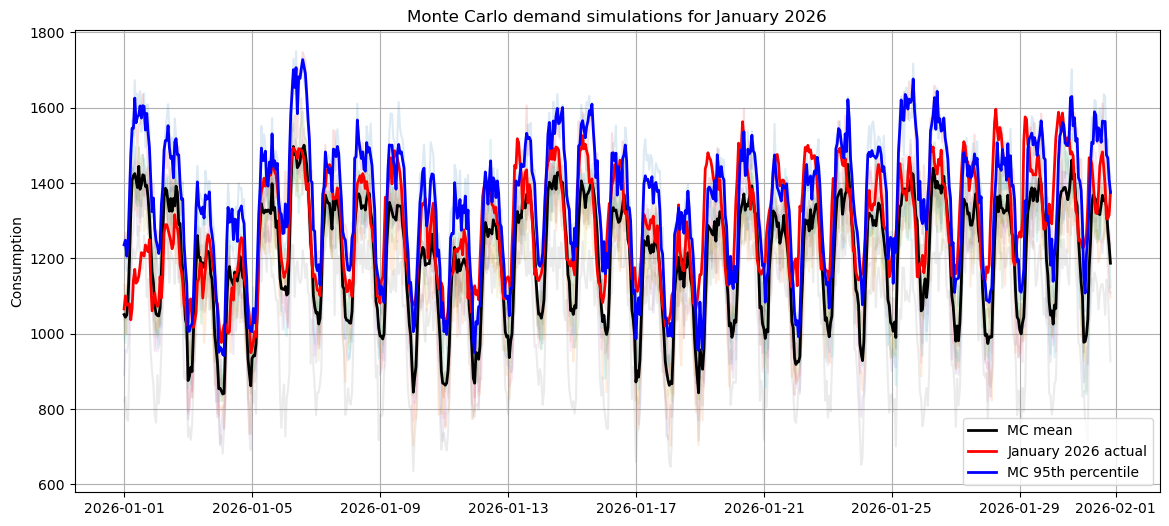

In [18]:
plt.figure(figsize=(14, 6))
q95 = demand_mc_2026.quantile(0.95, axis=1)

plt.plot(demand_mc_2026.index[:741], demand_mc_2026.iloc[:741, :], alpha=0.15)
plt.plot(
    demand_mc_2026.index[:741],
    demand_mc_2026.mean(axis=1)[:741],
    color="black",
    linewidth=2,
    label="MC mean"
)
plt.plot(
    demand_mc_2026.index[:741],
    demand_series[2026].values,
    color="red",
    linewidth=2,
    label="January 2026 actual"
)
plt.plot(
    demand_mc_2026.index[:741],
    q95[:741],
    color="blue",
    linewidth=2,
    label="MC 95th percentile"
)

plt.title("Monte Carlo demand simulations for January 2026")
plt.ylabel("Consumption")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import os
import warnings
warnings.filterwarnings("ignore")

# Re-run Monte Carlo with n_sims=1000 for the resilience simulator
print("Running Monte Carlo with n_sims=1000 ...")
demand_mc_2026_full = simulate_demand_ensemble_with_random_betas(
    fitted_models=fitted_models,
    X_future=X_2026,
    beta_stats=beta_stats,
    features=["temperature_roll24", "wind_speed", "weekend"],
    n_sims=1000,
    seed=42,
)
print(f"MC ensemble shape: {demand_mc_2026_full.shape}")

# Hourly quantiles
demand_p5   = demand_mc_2026_full.quantile(0.05, axis=1)
demand_p50  = demand_mc_2026_full.quantile(0.50, axis=1)
demand_p95  = demand_mc_2026_full.quantile(0.95, axis=1)
demand_mean = demand_mc_2026_full.mean(axis=1)

# Actual Jan 2026 consumption aligned to the same index
actual_2026 = demand_series[2026].reindex(demand_mc_2026_full.index)

# Save quantile summary (used by resilience notebook)
os.makedirs("../data", exist_ok=True)

summary = pd.DataFrame({
    "timestamp":      demand_mc_2026_full.index,
    "demand_actual":  actual_2026.values,
    "demand_p5":      demand_p5.values,
    "demand_p50":     demand_p50.values,
    "demand_p95":     demand_p95.values,
    "demand_mean":    demand_mean.values,
})
summary.to_csv("../data/demand_mc_jan2026.csv", index=False)
print(f"✓ Saved demand quantiles → data/demand_mc_jan2026.csv  ({len(summary)} rows)")
print(f"  P50 mean: {demand_p50.mean():.0f} MW  |  P95 mean: {demand_p95.mean():.0f} MW")
print(f"  Actual mean: {actual_2026.mean():.0f} MW")

Running Monte Carlo with n_sims=1000 ...
MC ensemble shape: (744, 1000)
✓ Saved demand quantiles → data/demand_mc_jan2026.csv  (744 rows)
  P50 mean: 1215 MW  |  P95 mean: 1424 MW
  Actual mean: 1287 MW
